In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Co-ordinate Quantization

We need to take all the the time positions possible, and turn them into integers to be tokenized using quantization.


This is done simply by scaling the numbers knowing their max range and rounding them

In [2]:
import torch

In [12]:
max_seconds = 60
num_tokens = 2048


original = torch.rand(1, 1000)*max_seconds
quantized = torch.round(original/max_seconds*num_tokens)
avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
print(avg_error.item()*1000, "ms")

7.167454343289137 ms


# Checking this on real coordinates

~7.5ms error seems fairly reasonable for quantizing into 2048 tokens

Let's see how this looks

In [4]:
from nanodrz.data import gather_speakers_from_folder, artificial_diarisation_sample
from nanodrz import data
from nanodrz.utils import play, visualise_annotation

speakers = data.libritts_test()
len(speakers)

/home/harry/diarisation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


39

19.48575


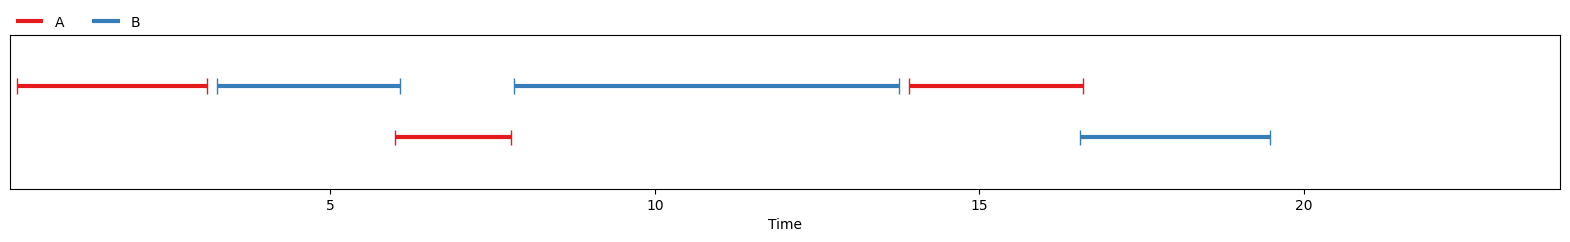

[0.1754375, 2.9294375, 'A']
[3.25425, 2.81875, 'B']
[5.999125, 1.7834375, 'A']
[7.836625, 5.921625, 'B']
[13.9191875, 2.6845, 'A']
[16.549812499999998, 2.9359375, 'B']


In [10]:
audio, labels = data.artificial_diarisation_sample(speakers, max_secs=30, num_speakers=2,  interrupt_sec_mean=.2, interrupt_var=.5)
print(audio.shape[-1]/16000)
visualise_annotation(labels)
print("\n".join(str(l) for l in labels))
play(audio, 16000)

tensor([[  6., 100.],
        [111.,  96.],
        [205.,  61.],
        [267., 202.],
        [475.,  92.],
        [565., 100.]])
5.059933755546808 ms
[[0.1754375, 2.9294375, 'A'], [3.25425, 2.81875, 'B'], [5.999125, 1.7834375, 'A'], [7.836625, 5.921625, 'B'], [13.9191875, 2.6845, 'A'], [16.549812499999998, 2.9359375, 'B']]


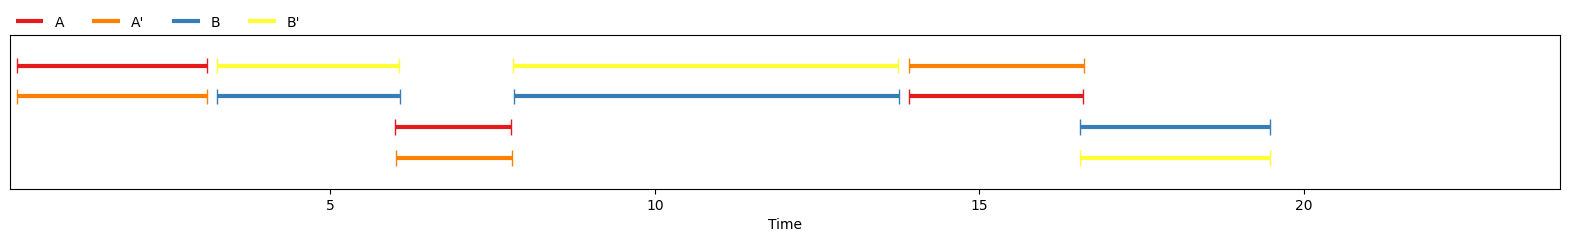

In [14]:
original = torch.tensor([[l[0], l[1]] for l in labels])
quantized = torch.round(original/max_seconds*num_tokens)
print(quantized)
unquantized =  quantized*max_seconds/num_tokens 
avg_error = torch.mean(torch.abs(original - unquantized))
print(avg_error.item()*1000, "ms")

# Visualise these labels

print(labels)
from copy import deepcopy

new_labels = deepcopy(labels)

for i, l in enumerate(new_labels):
    l[0] = unquantized[i][0]
    l[1] = unquantized[i][1]
    l[2] = l[2]+ "'"

# Let's see whether we can see a difference just for good measuer
visualise_annotation(labels+ new_labels)

# Desired Error Loop

Given a tolerable error e, what is the number of tokens we can get away with:

In [7]:
max_seconds = 60
num_tokens = 2048

# ms
e = 50

def compute_avg_error(num_tokens, max_seconds):
    original = torch.rand(1, 10000)*max_seconds
    quantized = torch.round(original/max_seconds*num_tokens)
    avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
    avg_error = avg_error.item()*1000
    print(num_tokens, max_seconds, "secs", avg_error, "ms")
    return avg_error
    

avg_error = compute_avg_error(num_tokens, max_seconds)
while avg_error < e:
    num_tokens -= 16
    avg_error = compute_avg_error(num_tokens, max_seconds)

2048 60 secs 7.308890577405691 ms
2032 60 secs 7.457618601620197 ms
2016 60 secs 7.466964889317751 ms
2000 60 secs 7.406269665807486 ms
1984 60 secs 7.524242624640465 ms
1968 60 secs 7.661374751478434 ms
1952 60 secs 7.677306421101093 ms
1936 60 secs 7.716367486864328 ms
1920 60 secs 7.788689341396093 ms
1904 60 secs 7.841938175261021 ms
1888 60 secs 7.981370203197002 ms
1872 60 secs 7.967867888510227 ms
1856 60 secs 7.986574433743954 ms
1840 60 secs 8.184351958334446 ms
1824 60 secs 8.235427550971508 ms
1808 60 secs 8.116593584418297 ms
1792 60 secs 8.401058614253998 ms
1776 60 secs 8.428942412137985 ms
1760 60 secs 8.545748889446259 ms
1744 60 secs 8.61127395182848 ms
1728 60 secs 8.680702187120914 ms
1712 60 secs 8.773637004196644 ms
1696 60 secs 8.81732627749443 ms
1680 60 secs 8.903948590159416 ms
1664 60 secs 9.034658782184124 ms
1648 60 secs 9.101282805204391 ms
1632 60 secs 9.210252203047276 ms
1616 60 secs 9.314272552728653 ms
1600 60 secs 9.381857700645924 ms
1584 60 secs 9.4